**LIBRERÍAS**

In [1]:
import random
import pandas as pd
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import zipfile
import struct
import copy
import torch.nn.functional as F
import os
import torch.optim as optim
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTEENN
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve,precision_recall_curve)

## Reproducibilidad

Usamos la semilla `42` en Python, NumPy y PyTorch para controlar las operaciones aleatorias. La misma constante se usa en la partición de entrenamiento y validación. Reiniciamos las semillas antes de crear el modelo para que cada ejecución del experimento comience desde el mismo estado aleatorio.


In [ ]:
SEED = 42

def set_seed(seed=SEED):
    # Controlar la aleatoriedad de Python, NumPy y PyTorch.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Favorecer operaciones reproducibles cuando se utiliza cuDNN.
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

set_seed()


Las semillas controlan la selección de imágenes, la inicialización de pesos, el dropout y el orden de los batches. Para repetir el flujo completo, se debe reiniciar el kernel y ejecutar todas las celdas en orden. Esto no garantiza resultados idénticos entre versiones de las librerías o equipos diferentes. Las salidas de entrenamiento guardadas previamente deberán actualizarse al ejecutar el experimento con esta configuración.


## Carga del dataset

Definimos `base_path` como la carpeta relativa al directorio de trabajo del notebook que se usará tanto para descargar como para leer los cuatro archivos IDX de MNIST. Así evitamos descargar en una ubicación y cargar desde otra.


In [ ]:
base_path = "datasets-problema2"
url = "https://drive.google.com/drive/folders/1mdExsONP4S3b5Czn6nR4cLIdsZGs9zDQ"

gdown.download_folder(
    url,
    output=base_path,
    quiet=False,
    use_cookies=False)


## Carga y verificación del formato IDX

Leemos los encabezados en big-endian y comprobamos los números mágicos, las dimensiones 28 × 28 y la longitud del contenido. Verificamos que cada imagen tenga una etiqueta entre 0 y 9 y que los conjuntos originales contengan 60.000 y 10.000 ejemplos. Usamos `ValueError` para que los controles permanezcan activos aunque Python se ejecute con optimizaciones.


In [ ]:
def load_mnist_images(filepath):
    with open(filepath, 'rb') as f:
        header = f.read(16)
        if len(header) != 16:
            raise ValueError(f"{filepath}: encabezado de imágenes incompleto")
        magic, num_images, rows, cols = struct.unpack('>IIII', header)
        if magic != 2051:
            raise ValueError(f"{filepath}: número mágico inválido: {magic}")
        if num_images == 0 or (rows, cols) != (28, 28):
            raise ValueError(f"{filepath}: dimensiones inválidas: {(num_images, rows, cols)}")

        # El contenido debe coincidir exactamente con lo declarado en el encabezado.
        pixels = np.frombuffer(f.read(), dtype=np.uint8)
        expected_pixels = num_images * rows * cols
        if pixels.size != expected_pixels:
            raise ValueError(f"{filepath}: se esperaban {expected_pixels} píxeles, se leyeron {pixels.size}")
    return pixels.reshape(num_images, rows, cols)


def load_mnist_labels(filepath):
    with open(filepath, 'rb') as f:
        header = f.read(8)
        if len(header) != 8:
            raise ValueError(f"{filepath}: encabezado de etiquetas incompleto")
        magic, num_labels = struct.unpack('>II', header)
        if magic != 2049:
            raise ValueError(f"{filepath}: número mágico inválido: {magic}")
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        if num_labels == 0 or labels.size != num_labels:
            raise ValueError(f"{filepath}: cantidad de etiquetas inválida: declaradas {num_labels}, leídas {labels.size}")
        if np.any(labels > 9):
            raise ValueError(f"{filepath}: las etiquetas deben estar entre 0 y 9")
    # Copiar evita compartir memoria de solo lectura al convertir las etiquetas a tensores.
    return labels.copy()


X_train = load_mnist_images(os.path.join(base_path, "train-images.idx3-ubyte"))
y_train = load_mnist_labels(os.path.join(base_path, "train-labels.idx1-ubyte"))
X_test = load_mnist_images(os.path.join(base_path, "t10k-images.idx3-ubyte"))
y_test = load_mnist_labels(os.path.join(base_path, "t10k-labels.idx1-ubyte"))

# Validar los pares originales antes de crear el conjunto de validación.
for name, images, labels, expected_count in (
    ("train original", X_train, y_train, 60000),
    ("test", X_test, y_test, 10000),
):
    if len(images) != len(labels) or len(images) != expected_count:
        raise ValueError(f"{name}: se esperaban {expected_count} imágenes y etiquetas; se recibieron {len(images)} y {len(labels)}")
    if images.dtype != np.uint8 or labels.dtype != np.uint8:
        raise ValueError(f"{name}: imágenes y etiquetas deben tener tipo uint8")
    print(f"{name}: {len(images)} imágenes y etiquetas verificadas (uint8, 28 × 28)")

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train)

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")


Los archivos originales superaron las comprobaciones de integridad y correspondencia entre imágenes y etiquetas. La partición estratificada reserva 12.000 ejemplos para validación y mantiene 48.000 para entrenamiento.

### Resumen de dimensiones, tipos y rangos

Mostramos los datos antes de normalizarlos. En arrays `uint8`, el conteo de NaN no aporta información porque ese tipo no representa NaN; los controles relevantes son la estructura, las cantidades y los rangos.


In [ ]:
datasets = {
    "train": (X_train, y_train),
    "validación": (X_val, y_val),
    "test": (X_test, y_test),
}

for name, (images, labels) in datasets.items():
    print(f"{name}: imágenes {images.shape}, {images.dtype}, "
          f"píxeles [{images.min()}, {images.max()}]; "
          f"etiquetas {labels.shape}, {labels.dtype}, "
          f"rango [{labels.min()}, {labels.max()}]")


Las imágenes conservan la forma 28 × 28 y el tipo `uint8`, con intensidades entre 0 y 255. Las etiquetas son vectores `uint8` con valores entre 0 y 9. Estos resultados permiten continuar con la exploración y el preprocesamiento.

## Análisis exploratorio de datos

### Muestra de imágenes

Mostramos 25 imágenes aleatorias del conjunto de entrenamiento con sus etiquetas para observar los trazos manuscritos y comprobar cómo se representan los dígitos en escala de grises.


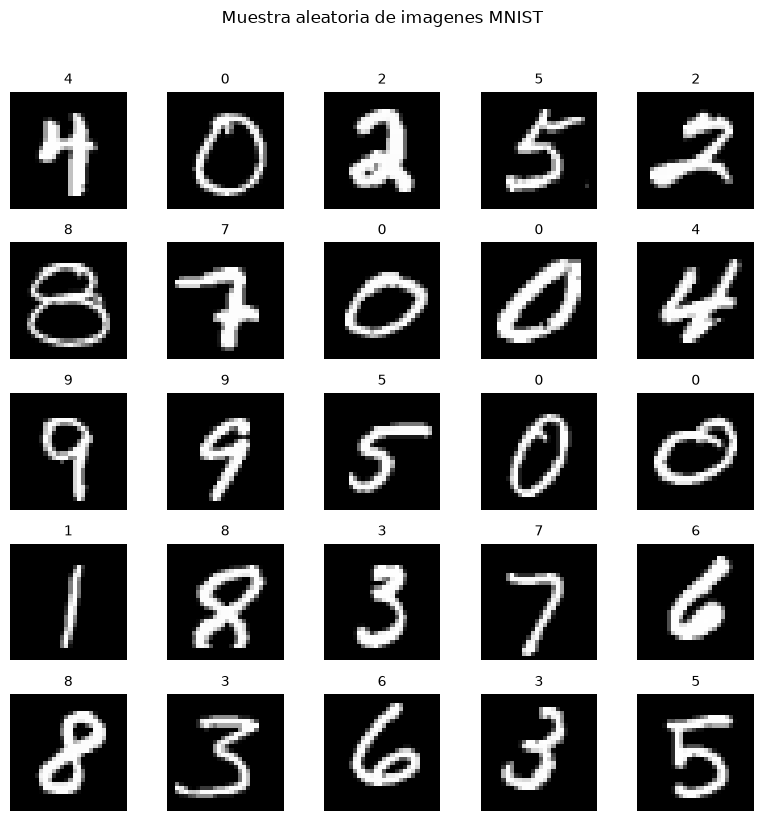

In [5]:
indices = np.random.choice(len(X_train), 25, replace=False)
fig, axes = plt.subplots(5, 5, figsize=(8, 8))

for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(y_train[idx], fontsize=10)
    ax.axis('off')
plt.suptitle("Muestra aleatoria de imagenes MNIST", y=1.02)
plt.tight_layout()
plt.show()

Las imágenes tienen fondo oscuro y trazos claros. La escritura manuscrita puede variar en inclinación, grosor y forma; esta variabilidad motiva el aprendizaje de patrones que generalicen a ejemplos nuevos. Una grilla pequeña permite una inspección visual, pero no prueba que todas las etiquetas sean correctas.

### Distribución de clases

Comparamos los conteos y porcentajes de cada dígito. La estratificación debe conservar proporciones similares entre entrenamiento y validación. Las frecuencias de test se describen sin utilizarlas para ajustar el modelo.


In [6]:
df_porcentajes = pd.DataFrame({
    "Train (%)": pd.Series(y_train).value_counts(normalize=True).sort_index() * 100,
    "Val (%)":   pd.Series(y_val).value_counts(normalize=True).sort_index() * 100,
    "Test (%)":  pd.Series(y_test).value_counts(normalize=True).sort_index() * 100,})

df_conteos = pd.DataFrame({
    "Train": pd.Series(y_train).value_counts().sort_index(),
    "Val":   pd.Series(y_val).value_counts().sort_index(),
    "Test":  pd.Series(y_test).value_counts().sort_index(),})

print("=== Conteo Absoluto por Clase ===")
print(df_conteos)

print("\n=== Porcentaje por Clase (%) ===")
print(df_porcentajes.round(2))

=== Conteo Absoluto por Clase ===
   Train   Val  Test
0   4738  1185   980
1   5394  1348  1135
2   4766  1192  1032
3   4905  1226  1010
4   4674  1168   982
5   4337  1084   892
6   4734  1184   958
7   5012  1253  1028
8   4681  1170   974
9   4759  1190  1009

=== Porcentaje por Clase (%) ===
   Train (%)  Val (%)  Test (%)
0       9.87     9.88      9.80
1      11.24    11.23     11.35
2       9.93     9.93     10.32
3      10.22    10.22     10.10
4       9.74     9.73      9.82
5       9.04     9.03      8.92
6       9.86     9.87      9.58
7      10.44    10.44     10.28
8       9.75     9.75      9.74
9       9.91     9.92     10.09


En entrenamiento, la clase más frecuente es el dígito 1 (5.394 ejemplos, 11,24 %) y la menos frecuente es el 5 (4.337 ejemplos, 9,04 %). El cociente entre ambos conteos es aproximadamente 1,24: hay diferencias pequeñas y las diez clases están representadas en proporciones cercanas al 10 %. Consideramos el dataset aproximadamente balanceado y no aplicamos sobremuestreo ni pesos de clase.

Validación conserva proporciones muy similares gracias a la partición estratificada. Este balance hace que accuracy sea un resumen razonable del rendimiento global; igualmente evaluaremos cada clase y la matriz de confusión para detectar dificultades que el promedio pueda ocultar.


**PREPROCESAMIENTO - APLANADO Y NORMALIZACIÓN**

In [7]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

print(f"X_train_flat: {X_train_flat.shape}") 
print(f"X_val_flat:   {X_val_flat.shape}")
print(f"X_test_flat:  {X_test_flat.shape}")

X_train_flat = X_train_flat.astype(np.float32) / 255.0
X_val_flat   = X_val_flat.astype(np.float32) / 255.0
X_test_flat  = X_test_flat.astype(np.float32) / 255.0

X_train_flat: (48000, 784)
X_val_flat:   (12000, 784)
X_test_flat:  (10000, 784)


In [8]:
df_train = pd.DataFrame(X_train_flat)

df_train['label'] = y_train

print("--- INFO ---")
df_train.info()

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Columns: 785 entries, 0 to label
dtypes: float32(784), uint8(1)
memory usage: 143.6 MB


### Distribución de intensidades antes y después de normalizar

Comparamos los mismos píxeles de entrenamiento usando 256 intervalos equivalentes: los bordes del segundo histograma son los del primero divididos por 255. Compartimos la escala vertical y usamos frecuencia logarítmica para visualizar las intensidades menos frecuentes junto con el predominio del fondo negro.


In [ ]:
# Un intervalo por intensidad uint8; transformar los bordes conserva los conteos.
pixel_bins = np.arange(257) - 0.5
normalized_bins = pixel_bins / 255.0
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(X_train.ravel(), bins=pixel_bins, color='gray', edgecolor='black', alpha=0.8)
axes[0].set_yscale('log')
axes[0].set_title("1. Píxeles sin normalizar (0 - 255)")
axes[0].set_xlabel("Valor de Píxel (0 a 255)")
axes[0].set_ylabel("Frecuencia (Escala Log)")
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].hist(X_train_flat.ravel(), bins=normalized_bins, color='darkblue', edgecolor='black', alpha=0.7)
axes[1].set_yscale('log')
axes[1].set_title("2. Píxeles normalizados (0.0 - 1.0)")
axes[1].set_xlabel("Intensidad Normalizada (0.0 a 1.0)")
axes[1].set_ylabel("Frecuencia (Escala Log)")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Predominan los píxeles de intensidad 0, correspondientes al fondo negro, y hay una concentración de intensidades altas asociada a los trazos claros. Los valores intermedios representan niveles de gris en los trazos y sus bordes.

La normalización cambia la escala de [0, 255] a [0, 1], pero conserva el orden de las intensidades y sus frecuencias. Por eso, con intervalos equivalentes, ambos histogramas tienen los mismos conteos. Esta operación no balancea las intensidades ni centra los datos en cero; proporciona entradas de menor escala para el entrenamiento.


**MLP**

In [10]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, output_dim, dropout_rate):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.fc3 = nn.Linear(hidden_dim2, output_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, x):
        x = x.flatten(start_dim=1)
        out = self.dropout(self.relu(self.fc1(x)))
        out = self.dropout(self.relu(self.fc2(out)))
        out = self.fc3(out)
        return out

In [11]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)  
 
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
 
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        n += x.size(0)
    return total_loss / n, correct / n


In [12]:
X_train_t = torch.as_tensor(X_train_flat, dtype=torch.float32)
y_train_t = torch.as_tensor(y_train, dtype=torch.long)
train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)


X_val_t = torch.as_tensor(X_val_flat, dtype=torch.float32)
y_val_t = torch.as_tensor(y_val, dtype=torch.long)
val_ds = TensorDataset(X_val_t, y_val_t)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)


X_test_t = torch.as_tensor(X_test_flat, dtype=torch.float32)
y_test_t = torch.as_tensor(y_test, dtype=torch.long)
test_ds = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

C:\Users\fjm25\AppData\Local\Temp\ipykernel_15800\971536808.py:14: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_test_t = torch.as_tensor(y_test, dtype=torch.long)


Epoch 01/30 | Train Loss: 0.5151 - Train Acc: 0.845 | Val Loss: 0.2087 - Val Acc: 0.938 | LR: 0.001000
Epoch 02/30 | Train Loss: 0.2430 - Train Acc: 0.929 | Val Loss: 0.1477 - Val Acc: 0.955 | LR: 0.001000
Epoch 03/30 | Train Loss: 0.1892 - Train Acc: 0.944 | Val Loss: 0.1280 - Val Acc: 0.961 | LR: 0.001000
Epoch 04/30 | Train Loss: 0.1589 - Train Acc: 0.953 | Val Loss: 0.1120 - Val Acc: 0.966 | LR: 0.001000
Epoch 05/30 | Train Loss: 0.1423 - Train Acc: 0.957 | Val Loss: 0.1016 - Val Acc: 0.968 | LR: 0.001000
Epoch 06/30 | Train Loss: 0.1262 - Train Acc: 0.962 | Val Loss: 0.0988 - Val Acc: 0.972 | LR: 0.001000
Epoch 07/30 | Train Loss: 0.1145 - Train Acc: 0.965 | Val Loss: 0.0976 - Val Acc: 0.972 | LR: 0.001000
Epoch 08/30 | Train Loss: 0.1114 - Train Acc: 0.966 | Val Loss: 0.0916 - Val Acc: 0.974 | LR: 0.001000
Epoch 09/30 | Train Loss: 0.1003 - Train Acc: 0.969 | Val Loss: 0.0900 - Val Acc: 0.974 | LR: 0.001000
Epoch 10/30 | Train Loss: 0.0995 - Train Acc: 0.970 | Val Loss: 0.0885 - 

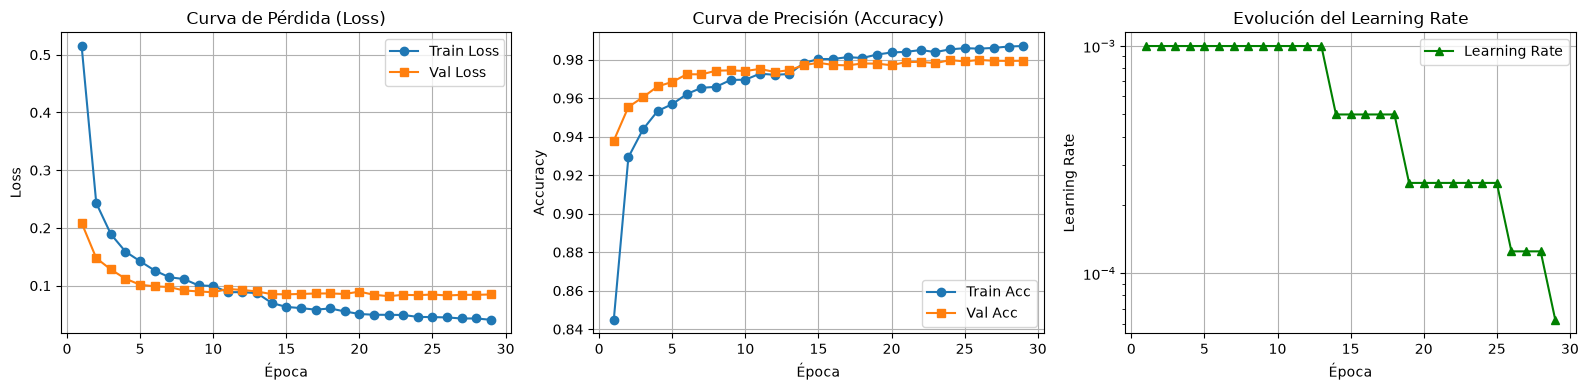

In [ ]:
# Reiniciar la aleatoriedad antes de inicializar y entrenar el modelo.
set_seed()

IN_FEATURES = 784
N_CLASSES = 10

device = "cuda" if torch.cuda.is_available() else "cpu"

model = MLP(input_dim=IN_FEATURES,
    hidden_dim1=128,
    hidden_dim2=64,
    output_dim=N_CLASSES,
    dropout_rate=0.3,).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="min",factor=0.5,patience=2,)

patience_es = 7        
patience_counter = 0
best_val_loss = float("inf")
best_model_weights = None

train_losses, train_accs = [], []
val_losses, val_accs = [], []
lr_history = []

epochs = 30
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)

            val_loss += loss.item() * X_batch.size(0)

            _, preds = torch.max(outputs, dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)

    val_acc = val_correct / val_total
    avg_val_loss = val_loss / val_total

    current_lr = optimizer.param_groups[0]["lr"]
    lr_history.append(current_lr)

    scheduler.step(avg_val_loss)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch + 1:02d}/{epochs} | "
          f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.3f} | "
          f"Val Loss: {avg_val_loss:.4f} - Val Acc: {val_acc:.3f} | "
          f"LR: {current_lr:.6f}")


    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(best_model_weights, "best_model.pt") 
        patience_counter = 0 
    else:
        patience_counter += 1
        if patience_counter >= patience_es:
            print(f"\n[Early Stopping] Se detuvo en la época {epoch + 1} por falta de mejora en val_loss.")
            break

if best_model_weights is not None:
    model.load_state_dict(best_model_weights)
    print("\n Se cargaron los pesos del mejor checkpoint en el modelo.")

model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = loss_fn(outputs, y_batch)

        test_loss += loss.item() * X_batch.size(0)

        _, preds = torch.max(outputs, dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

accuracy = correct / total
avg_test_loss = test_loss / total

print("\n" + "=" * 50)
print(f"Test Loss: {avg_test_loss:.4f} | Test Accuracy: {accuracy * 100:.2f}%")
print("=" * 50 + "\n")

epochs_ran = len(train_losses)

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.plot(range(1, epochs_ran + 1), train_losses, label="Train Loss", marker="o")
plt.plot(range(1, epochs_ran + 1), val_losses, label="Val Loss", marker="s")
plt.title("Curva de Pérdida (Loss)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(range(1, epochs_ran + 1), train_accs, label="Train Acc", marker="o")
plt.plot(range(1, epochs_ran + 1), val_accs, label="Val Acc", marker="s")
plt.title("Curva de Precisión (Accuracy)")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(range(1, epochs_ran + 1), lr_history, label="Learning Rate", color="green", marker="^")
plt.title("Evolución del Learning Rate")
plt.xlabel("Época")
plt.ylabel("Learning Rate")
plt.yscale("log")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**TEST**

 Accuracy de cada Clase
Clase 0: 99.18%
Clase 1: 98.77%
Clase 2: 97.87%
Clase 3: 98.51%
Clase 4: 97.56%
Clase 5: 97.76%
Clase 6: 97.91%
Clase 7: 97.57%
Clase 8: 96.51%
Clase 9: 96.93%

 Reporte 
              precision    recall  f1-score   support

           0     0.9789    0.9918    0.9853       980
           1     0.9885    0.9877    0.9881      1135
           2     0.9749    0.9787    0.9768      1032
           3     0.9698    0.9851    0.9774      1010
           4     0.9785    0.9756    0.9771       982
           5     0.9820    0.9776    0.9798       892
           6     0.9832    0.9791    0.9812       958
           7     0.9728    0.9757    0.9743      1028
           8     0.9771    0.9651    0.9711       974
           9     0.9809    0.9693    0.9751      1009

    accuracy                         0.9787     10000
   macro avg     0.9787    0.9786    0.9786     10000
weighted avg     0.9787    0.9787    0.9787     10000



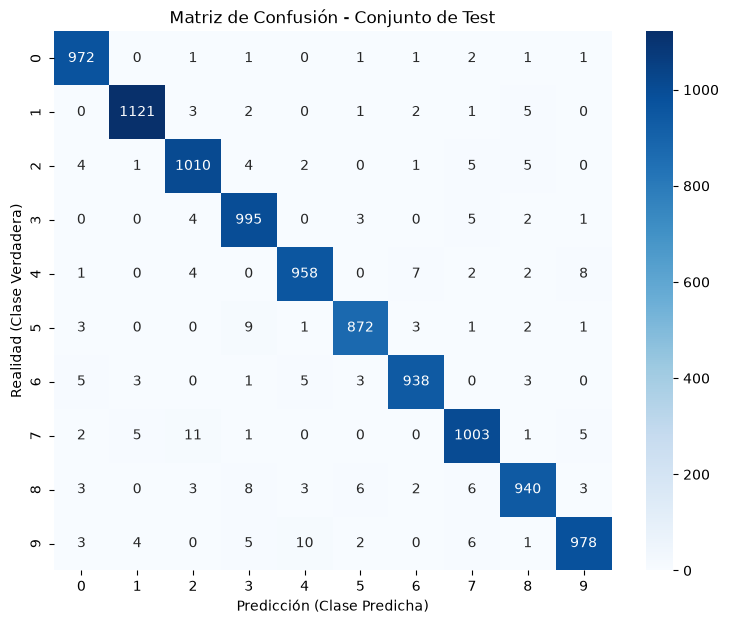


 PARES DE DÍGITOS CON MAYOR CONFUSIÓN
Real     | Predicho   | Cantidad de Errores
------------------------------------------
Dígito 7  | Dígito 2    | 11 errores
Dígito 9  | Dígito 4    | 10 errores
Dígito 5  | Dígito 3    | 9 errores
Dígito 4  | Dígito 9    | 8 errores
Dígito 8  | Dígito 3    | 8 errores


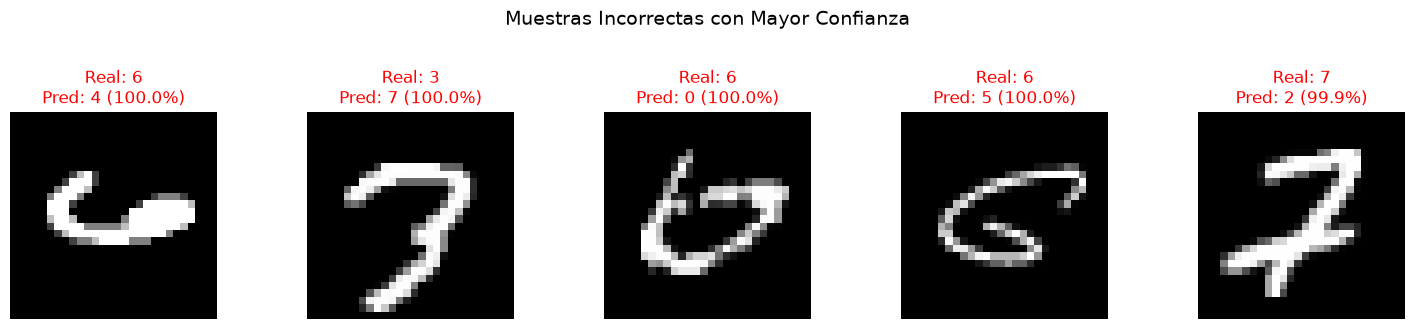

In [18]:


model.eval()
test_loss = 0.0
correct = 0
total = 0

all_preds = []
all_targets = []
all_probs = []
all_images = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch_dev, y_batch_dev = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch_dev)
        loss = loss_fn(outputs, y_batch_dev)

        test_loss += loss.item() * X_batch.size(0)

        probs = F.softmax(outputs, dim=1)
        max_probs, preds = torch.max(probs, dim=1)

        correct += (preds == y_batch_dev).sum().item()
        total += y_batch_dev.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch_dev.cpu().numpy())
        all_probs.extend(max_probs.cpu().numpy())
        all_images.extend(X_batch.numpy())

accuracy = correct / total
avg_test_loss = test_loss / total

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs = np.array(all_probs)
all_images = np.array(all_images)

cm = confusion_matrix(all_targets, all_preds)
class_accuracies = cm.diagonal() / cm.sum(axis=1)

print(" Accuracy de cada Clase")
for cls, acc in enumerate(class_accuracies):
    print(f"Clase {cls}: {acc * 100:.2f}%")

print("\n Reporte ")
print(classification_report(all_targets, all_preds, digits=4))

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=range(10), yticklabels=range(10))
plt.title("Matriz de Confusión - Conjunto de Test")
plt.xlabel("Predicción (Clase Predicha)")
plt.ylabel("Realidad (Clase Verdadera)")
plt.show()

confusions = []
for true_class in range(10):
    for pred_class in range(10):
        if true_class != pred_class:
            count = cm[true_class, pred_class]
            if count > 0:
                confusions.append((true_class, pred_class, count))

confusions.sort(key=lambda x: x[2], reverse=True)

print("\n PARES DE DÍGITOS CON MAYOR CONFUSIÓN")
print(f"{'Real':<8} | {'Predicho':<10} | {'Cantidad de Errores':<18}")
print("-" * 42)
for true_c, pred_c, count in confusions[:5]:
    print(f"Dígito {true_c:<2} | Dígito {pred_c:<4} | {count} errores")

incorrect_mask = (all_preds != all_targets)
incorrect_indices = np.where(incorrect_mask)[0]
incorrect_probs = all_probs[incorrect_mask]

top_confident_error_indices = incorrect_indices[np.argsort(incorrect_probs)[::-1][:5]]

plt.figure(figsize=(15, 3))
for i, idx in enumerate(top_confident_error_indices):
    img = all_images[idx]
    
    if img.ndim == 1 or img.shape[0] == 784:
        img = img.reshape(28, 28)
    elif img.ndim == 3 and img.shape[0] == 1:
        img = img.squeeze(0)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Real: {all_targets[idx]}\nPred: {all_preds[idx]} ({all_probs[idx]*100:.1f}%)", color="red")
    plt.axis("off")

plt.suptitle("Muestras Incorrectas con Mayor Confianza", fontsize=14, y=1.08)
plt.tight_layout()
plt.show()

**OVERFITTING**
Sobreajuste leve. Las curvas de pérdida se cruzan alrededor de la época 12; a partir de ahí la pérdida de entrenamiento continúa descendiendo (~0.04) mientras que la de validación se estabiliza (~0.085). La brecha de accuracy es inferior a 1 punto porcentual (0.987 en entrenamiento frente a 0.980 en validación). Este comportamiento indica un ajuste leve al conjunto de entrenamiento, pero no un sobreajuste severo: la pérdida de validación no aumenta y la accuracy de validación no disminuye. La evaluación final en el conjunto de test (accuracy 97.78%, loss 0.0748) es consistente con la validación, lo que confirma que el modelo generaliza adecuadamente. Se aplicaron dropout (0.3), ReduceLROnPlateau y early stopping para controlarlo.